<div style="background: linear-gradient(to right, #4facfe 0%, #00f2fe 100%); padding: 20px; border-radius: 10px; color: white;">
<h1 style="color: white; margin: 0;"> Exploring Mental Health Data</h1>
<p style="font-size: 16px; margin: 5px 0;"><strong>Course:</strong> PTDLTM | <strong>Team:</strong> Hít Khí Trời Làm Data | <strong>Date:</strong> 14/04/2026</p>
</div>

## **1.Business Context**

### **Business Context: The Impact of Depression** 
Trầm cảm (Depression) là một trong những nguyên nhân hàng đầu gây ra khuyết tật và suy giảm chất lượng cuộc sống trên toàn cầu. Theo số liệu từ Tổ chức Y tế Thế giới (WHO), khoảng 280 triệu người trên khắp thế giới bị trầm cảm. Việc **chẩn đoán và phát hiện sớm** (early detection) là cực kỳ quan trọng để ngăn ngừa các hậu quả đặc biệt nghiêm trọng. 
Machine Learning đóng vai trò thiết yếu giúp phân tích mối liên hệ phức tạp tiềm ẩn giữa yếu tố cuộc sống (áp lực học tập/làm việc, thói quen sinh hoạt) đến sự dịch chuyển về sức khỏe tinh thần một cách khách quan.

### **Dataset Source**
Bộ dữ liệu này được lấy tham chiếu từ **Kaggle Playground Series (S4E11)**. Đây là một bộ dữ liệu **synthetic (tổng hợp)** được sinh ra dựa trên đặc trưng phân phối của các bộ dữ liệu sức khỏe tâm lý thế giới thực. 
*Tại sao lại dùng Synthetic Data?* Dữ liệu y tế và tâm lý học cực kỳ nhạy cảm và bị bảo vệ quyền riêng tư nghiêm ngặt. Việc sử dụng synthetic data đảm bảo mã nguồn mở không xâm phạm quyền riêng tư nhưng vẫn phân tích được những "insights" có giá trị giống hệt dữ liệu thực tế.



## **2.Dataset Overview**


**Import Thư Viện và Setting**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import os
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

# Load data
train_df = pd.read_csv('../data/raw/train.csv')
test_df = pd.read_csv('../data/raw/test.csv')

pd.set_option('display.max_columns', None)


**Basic Info**

In [2]:
print(f"Train Shape: {train_df.shape}")
print(f"Test Shape: {test_df.shape}")

train_size = os.path.getsize('../data/raw/train.csv') / (1024 * 1024)
test_size = os.path.getsize('../data/raw/test.csv') / (1024 * 1024)
print(f"Train File Size: {train_size:.2f} MB")
print(f"Test File Size: {test_size:.2f} MB")

print("\nMemory Usage:")
train_df.info(memory_usage='deep')


Train Shape: (140700, 20)
Test Shape: (93800, 19)
Train File Size: 15.78 MB
Test File Size: 10.41 MB

Memory Usage:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140700 entries, 0 to 140699
Data columns (total 20 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   id                                     140700 non-null  int64  
 1   Name                                   140700 non-null  object 
 2   Gender                                 140700 non-null  object 
 3   Age                                    140700 non-null  float64
 4   City                                   140700 non-null  object 
 5   Working Professional or Student        140700 non-null  object 
 6   Profession                             104070 non-null  object 
 7   Academic Pressure                      27897 non-null   float64
 8   Work Pressure                          112782 non-null  float64
 9   CGPA     

In [3]:
train_df.describe()

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
count,140700.000000,140700.000000,27897.000000,112782.000000,27898.000000,27897.000000,112790.000000,140700.000000,140696.000000,140700.000000
mean,70349.500000,40.388621,3.142273,2.998998,7.658636,2.944940,2.974404,6.252679,2.988983,0.181713
std,40616.735775,12.384099,1.380457,1.405771,1.464466,1.360197,1.416078,3.853615,1.413633,0.385609
min,0.000000,18.000000,1.000000,1.000000,5.030000,1.000000,1.000000,0.000000,1.000000,0.000000
25%,35174.750000,29.000000,2.000000,2.000000,6.290000,2.000000,2.000000,3.000000,2.000000,0.000000
50%,70349.500000,42.000000,3.000000,3.000000,7.770000,3.000000,3.000000,6.000000,3.000000,0.000000
75%,105524.250000,51.000000,4.000000,4.000000,8.920000,4.000000,4.000000,10.000000,4.000000,0.000000
max,140699.000000,60.000000,5.000000,5.000000,10.000000,5.000000,5.000000,12.000000,5.000000,1.000000


In [4]:
train_df.head(10)

,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,Aaradhya,Female,49.0,Ludhiana,Working Professional,Chef,NaN,5.0,NaN,NaN,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0
1,1,Vivan,Male,26.0,Varanasi,Working Professional,Teacher,NaN,4.0,NaN,NaN,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1
2,2,Yuvraj,Male,33.0,Visakhapatnam,Student,NaN,5.0,NaN,8.97,2.0,NaN,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
3,3,Yuvraj,Male,22.0,Mumbai,Working Professional,Teacher,NaN,5.0,NaN,NaN,1.0,Less than 5 hours,Moderate,BBA,Yes,10.0,1.0,Yes,1
4,4,Rhea,Female,30.0,Kanpur,Working Professional,Business Analyst,NaN,1.0,NaN,NaN,1.0,5-6 hours,Unhealthy,BBA,Yes,9.0,4.0,Yes,0
5,5,Vani,Female,59.0,Ahmedabad,Working Professional,Finanancial Analyst,NaN,2.0,NaN,NaN,5.0,5-6 hours,Healthy,MCA,No,7.0,5.0,No,0
6,6,Ritvik,Male,47.0,Thane,Working Professional,Chemist,NaN,5.0,NaN,NaN,2.0,7-8 hours,Moderate,MD,No,6.0,2.0,No,0
7,7,Rajveer,Male,38.0,Nashik,Working Professional,Teacher,NaN,3.0,NaN,NaN,4.0,7-8 hours,Unhealthy,B.Pharm,No,10.0,3.0,Yes,0
8,8,Aishwarya,Female,24.0,Bangalore,Student,NaN,2.0,NaN,5.90,5.0,NaN,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
9,9,Simran,Female,42.0,Patna,Working Professional,Electrician,NaN,4.0,NaN,NaN,1.0,5-6 hours,Healthy,ME,Yes,7.0,2.0,Yes,0


In [5]:
train_df.tail(10)

,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
140690,140690,Rashi,Female,18.0,Ludhiana,Student,NaN,5.0,NaN,6.88,2.0,NaN,Less than 5 hours,Healthy,Class 12,Yes,10.0,5.0,No,1
140691,140691,Zara,Female,57.0,Meerut,Working Professional,Teacher,NaN,1.0,NaN,NaN,1.0,Less than 5 hours,Moderate,B.Arch,Yes,4.0,5.0,Yes,0
140692,140692,Raunak,Male,49.0,Bhopal,Working Professional,Financial Analyst,NaN,4.0,NaN,NaN,1.0,7-8 hours,Moderate,MBA,No,9.0,1.0,No,0
140693,140693,Shaurya,Male,55.0,Srinagar,Working Professional,Data Scientist,NaN,1.0,NaN,NaN,3.0,Less than 5 hours,Unhealthy,M.Tech,No,9.0,2.0,No,0
140694,140694,Ishaani,Female,45.0,Ahmedabad,Working Professional,Teacher,NaN,2.0,NaN,NaN,5.0,Less than 5 hours,Moderate,B.Ed,Yes,1.0,5.0,No,0
140695,140695,Vidya,Female,18.0,Ahmedabad,Working Professional,NaN,NaN,5.0,NaN,NaN,4.0,5-6 hours,Unhealthy,Class 12,No,2.0,4.0,Yes,1
140696,140696,Lata,Female,41.0,Hyderabad,Working Professional,Content Writer,NaN,5.0,NaN,NaN,4.0,7-8 hours,Moderate,B.Tech,Yes,6.0,5.0,Yes,0
140697,140697,Aanchal,Female,24.0,Kolkata,Working Professional,Marketing Manager,NaN,3.0,NaN,NaN,1.0,More than 8 hours,Moderate,B.Com,No,4.0,4.0,No,0
140698,140698,Prachi,Female,49.0,Srinagar,Working Professional,Plumber,NaN,5.0,NaN,NaN,2.0,5-6 hours,Moderate,ME,Yes,10.0,1.0,No,0
140699,140699,Sai,Male,27.0,Patna,Student,NaN,4.0,NaN,9.24,1.0,NaN,Less than 5 hours,Healthy,BCA,Yes,2.0,3.0,Yes,1


### 1. Basic Info Markdown

Mỗi row trong tập dữ liệu đại diện cho **1 đối tượng tham gia khảo sát (survey respondent)**. Các columns là kết quả của bảng khảo sát ghi nhận về tuổi, giới tính, điều kiện công việc/học tập, sự áp lực, và kết luận họ có bị Depressed hay không.

### 2. Kiểu dữ liệu (Data Types)
- Bộ dữ liệu có sự kết hợp của **3 kiểu dữ liệu chính**: `int64` (3 cột), `float64` (7 cột), và `object` (10 cột).
- Các cột `id` và `Name` là định danh cá nhân, có thể xem xét **loại bỏ trong quá trình huấn luyện mô hình** vì thường không mang lại giá trị dự đoán, thậm chí có thể gây nhiễu.
- **Biến mục tiêu (Target)**: `Depression` (đang ở kiểu `int64`), chứng tỏ khả năng cao đây là bài toán phân loại nhị phân (Binary Classification - 0 hoặc 1).

### 3. Tình trạng Dữ liệu bị thiếu (Missing Values)
Có một cấu trúc khuyết thiếu dữ liệu (missing data) mang tính logic rất rõ ràng, phụ thuộc rẽ nhánh vào cột `Working Professional or Student`:
- **Nhóm sinh viên (Students)**: Các cột liên quan đến học thuật như `Academic Pressure` (~27.897 non-null), `CGPA` (~27.898 non-null), `Study Satisfaction` (~27.897 non-null) có số lượng bản ghi xấp xỉ nhau (~28k). Điều này khớp với số lượng lượng sinh viên trong bộ dữ liệu. Với những người đi làm, các cột này bị bỏ trống (NaN).
- **Nhóm người đi làm (Working Professionals)**: Các cột liên quan đến công việc như `Profession` (~104.070 non-null), `Work Pressure` (~112.782 non-null), `Job Satisfaction` (~112.790 non-null) có lượng dữ liệu đáp ứng vừa vặn với nhóm người đi làm. Trái lại, sinh viên sẽ bị khuyết các giá trị này.
- **Khuyết thiếu ngẫu nhiên/thiểu số**: Một số cột như `Dietary Habits` (thiếu 4 dòng), `Degree` (thiếu 2 dòng), `Financial Stress` (thiếu 4 dòng) có lượng missing value cực kỳ nhỏ, gần như không đáng kể.

### 4. Khuyến nghị Tiền xử lý (Preprocessing Recommendations)
- **Xử lý Missing Values có điều kiện**: **KHÔNG** nên điền các giá trị thiếu ở các cột có tính đặc thù riêng biệt (như `CGPA`, `Work Pressure`) bằng Mean/Median chung của toàn bộ dữ liệu. Thay vào đó:
  - Có thể điền một giá trị đại diện (vd: `-1` hoặc `0`) để mô hình hiểu rằng đặc trưng đó không áp dụng cho đối tượng tương ứng.
  - Hoặc tiến hành rẽ nhánh tạo thành **2 mô hình riêng biệt** (một Model cho Student và một Model cho Professional) nếu cần tối ưu tính chính xác cao.
- **Điền khuyết thiếu thiểu số (Imputation)**: Có thể dùng `mode()` (giá trị xuất hiện nhiều nhất) hoặc `median()` (trung vị) cho các cột bị khuyết vô cùng ít như `Dietary Habits`, `Degree`, `Financial Stress`, hoặc đơn giản là drop thẳng các dòng bị thiếu này đi vì số lượng quá bé (< 5 dòng) không ảnh hưởng tới phân bố tĩnh.
- **Mã hóa biến phân loại (Encoding)**: Rất nhiều cột Categorical (ví dụ: `Gender`, `City`, `Sleep Duration`, `Dietary Habits`, `Have you ever had suicidal thoughts ?`, `Family History of Mental Illness`) sẽ cần được mã hóa bằng **One-Hot Encoding** hoặc **Label Encoding** trước khi đưa vào đào tạo các mô hình Machine Learning.



## 3. Data Integrity


In [6]:
# Task 8: Duplicate Check
duplicate_count = train_df.duplicated().sum()
print(f"Total globally duplicated rows: {duplicate_count}")

# Check duplicates ignoring 'id' column
if 'id' in train_df.columns:
    duplicate_no_id = train_df.drop(columns=['id']).duplicated().sum()
    print(f"Total duplicated rows (ignoring 'id'): {duplicate_no_id}")
    
    if duplicate_no_id > 0:
        display(train_df[train_df.drop(columns=['id']).duplicated(keep=False)].sort_values(by=train_df.columns.drop('id').tolist()).head(4))


Total globally duplicated rows: 0
Total duplicated rows (ignoring 'id'): 0


### Duplicate Decision
**Quyết định:** Giữ lại (Keep).
**Giải thích (Justify):** Với các bài toán khảo sát thu thập, có khả năng 2 sinh viên có cùng các đặc điểm như giới tính, tuổi tác, môi trường, cảm xúc. Trừ khi cột `id` giống hệt nhau, còn nếu chỉ các values giống nhau thì việc bỏ duplicate có thể khiến mất phần lớn dữ liệu phân phối thực của nhóm dân số đông.


In [7]:
# Empty Row Check
empty_row_count = train_df.isnull().all(axis=1).sum()
print(f"Total rows completely empty: {empty_row_count}")


Total rows completely empty: 0


## 4. Column Inventory

###  Column Definition Table
| Cột | Phân loại | Ý nghĩa / Định nghĩa |
|---|---|---|
| `id` | Identifier | ID người người tham gia |
| `Name` | Identifier | Tên người dùng |
| `Gender` | Categorical | Giới tính |
| `Age` | Numerical | Độ tuổi |
| `City` | Categorical | Nơi cư trú |
| `Working Professional or Student` | Categorical | Tình trạng lao động/học tập |
| `Profession` | Categorical | Ngành nghề / Môn học |
| `Academic Pressure` | Numerical | Chỉ số áp lực học tập |
| `Work Pressure` | Numerical | Chỉ số áp lực công việc |
| `CGPA` | Numerical | Điểm hệ số |
| `Study Satisfaction` | Numerical | Điểm hài lòng học hành |
| `Job Satisfaction` | Numerical | Điểm hài lòng công việc |
| `Sleep Duration` | Ordinal Categorical | Thói quen ngủ |
| `Dietary Habits` | Ordinal Categorical | Thói quen ăn uống |
| `Degree` | Categorical | Bằng cấp cao nhất |
| `Have you ever had suicidal thoughts ?` | Categorical (Binary) | Từng suy nghĩ tự tử? |
| `Work/Study Hours` | Numerical | Số giờ làm việc / học mỗi ngày |
| `Financial Stress` | Numerical | Điểm số căng thẳng tài chính |
| `Family History of Mental Illness` | Categorical (Binary) | Có tiền sử bệnh tâm lý gia đình? |
| `Depression` | Target (Binary) | Trầm cảm (Predictive Target) |



In [8]:
# Thống kê lượng cardindality để check độ relevance
for col in ['id', 'Name']:
    if col in train_df.columns:
        print(f"'{col}': {train_df[col].nunique()} unique values / {len(train_df)} rows")


'id': 140700 unique values / 140700 rows
'Name': 422 unique values / 140700 rows


### Drop Decision
**Cột cần drop:** `id`, `Name`.

**Lý do:** Những cột định danh cá nhân độc nhất không chứa thông tin predictive (**Data Leakage**). Drop chúng để tăng chất lượng Data Mining.


## 5. Data Types


In [9]:
# dtype Check
dtypes_summary = train_df.dtypes.to_frame(name='Data Type').reset_index().rename(columns={'index': 'Feature'})
display(dtypes_summary)


,Feature,Data Type
0,id,int64
1,Name,object
2,Gender,object
3,Age,float64
4,City,object
5,Working Professional or Student,object
6,Profession,object
7,Academic Pressure,float64
8,Work Pressure,float64
9,CGPA,float64


### Inappropriate Types
Qua cái nhìn sơ bộ:
- Cột `Age` đang lưu bằng định dạng Float, tuy nhiên logic độ tuổi ở dạng khảo sát nguyên nên là `int`.
- `Sleep Duration` và `Dietary Habits` được lưu bằng Chuỗi (Object) nhưng tính chất thật sự của chúng mang yếu tố tuyến tính/thứ tự (Ordinal) (Kém -> Vừa -> Tốt).


In [10]:
# Task 16: Type Conversion
df_clean = train_df.copy()

# Xác định danh sách num_cols, cat_cols. Cần drop ids ra khỏi EDA
to_drop = ['id', 'Name']
for d in to_drop:
    if d in df_clean.columns: df_clean = df_clean.drop(columns=[d])

num_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
cat_cols = df_clean.select_dtypes(exclude=np.number).columns.tolist()

target_col = 'Depression'

# Hiển thị list để dùng phía dưới
print(f"Categorical Cols ({len(cat_cols)}):", cat_cols)
print(f"Numerical Cols ({len(num_cols)}):", num_cols)


Categorical Cols (9): ['Gender', 'City', 'Working Professional or Student', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']
Numerical Cols (9): ['Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress', 'Depression']


## 6. Numerical Analysis


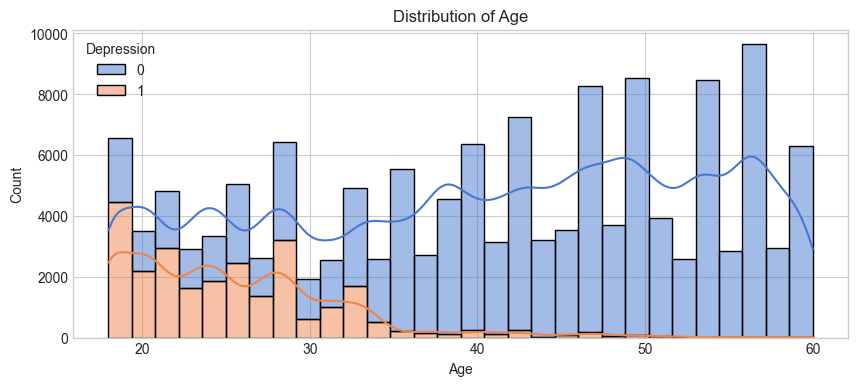

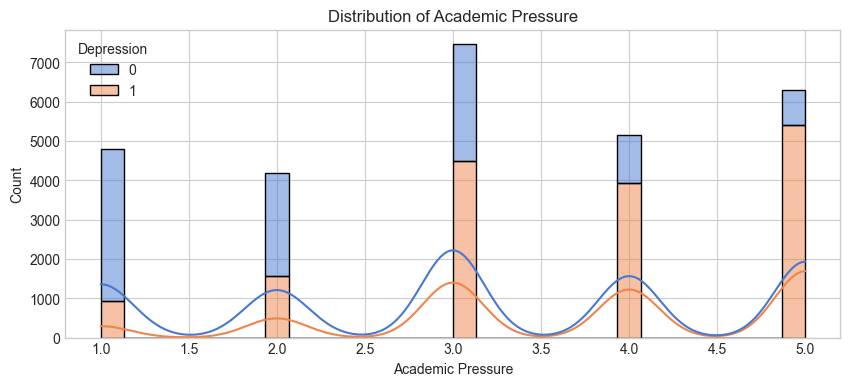

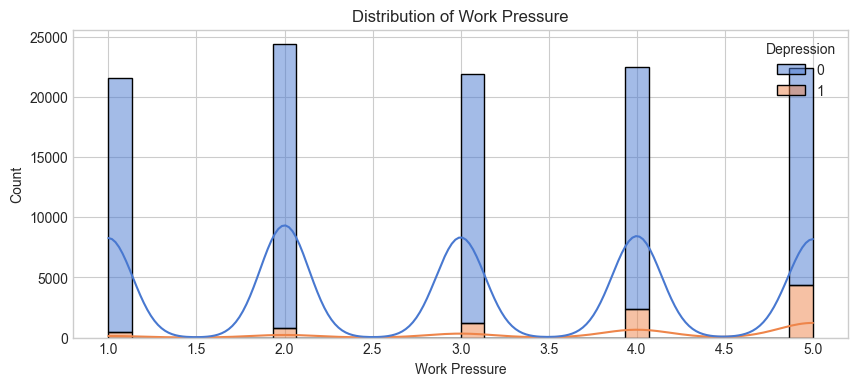

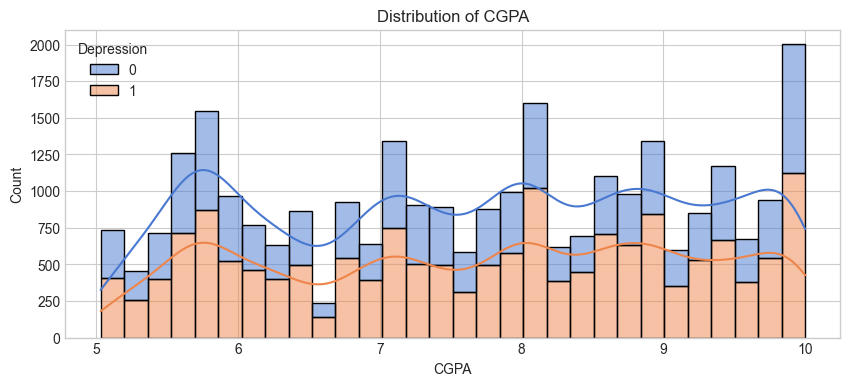

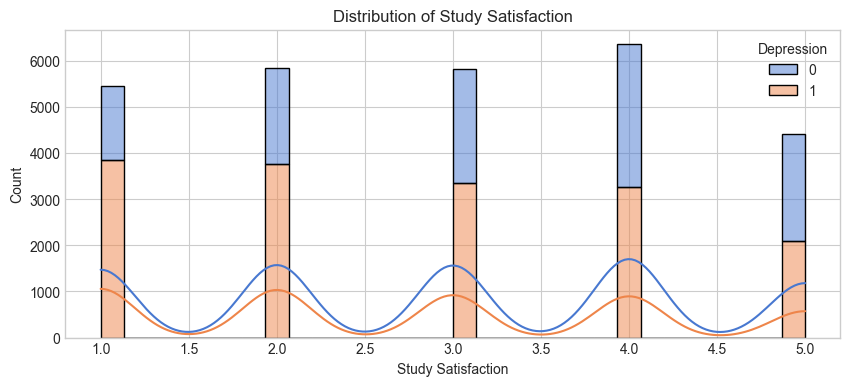

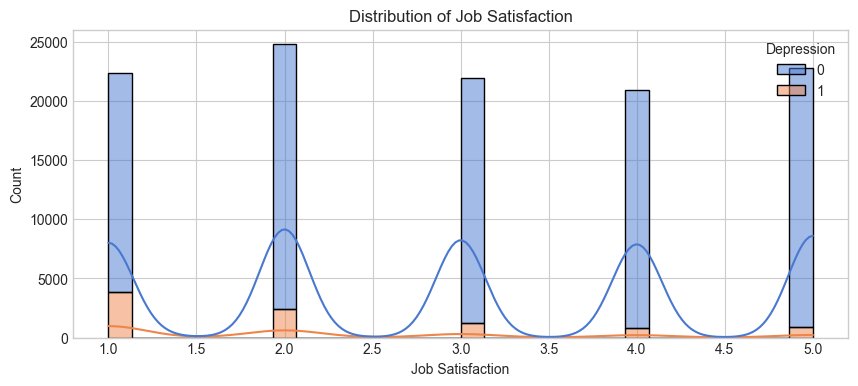

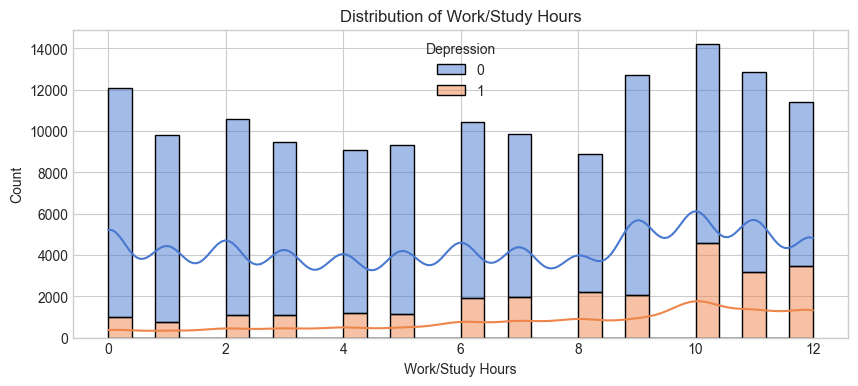

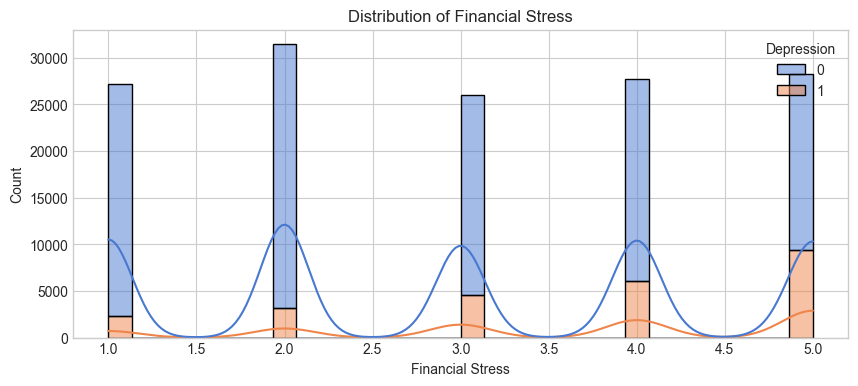

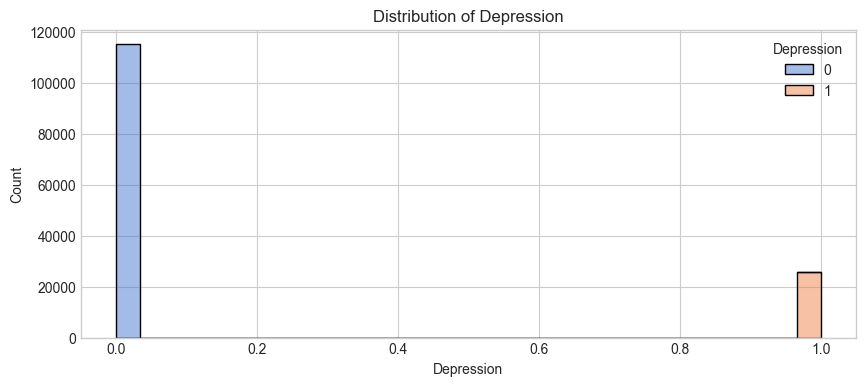

In [11]:
# Distribution Code (Hist + KDE)
for col in num_cols:
    plt.figure(figsize=(10, 4))
    if target_col in df_clean.columns:
        sns.histplot(data=df_clean, x=col, hue=target_col, kde=True, bins=30, alpha=0.5, multiple="stack")
    else:
        sns.histplot(data=df_clean, x=col, kde=True, bins=30, color='teal')
    plt.title(f'Distribution of {col}')

In [12]:
# Central Tendency
tendency = pd.DataFrame()
tendency['Mean'] = df_clean[num_cols].mean()
tendency['Median'] = df_clean[num_cols].median()
tendency['Std'] = df_clean[num_cols].std()
tendency['Skewness'] = df_clean[num_cols].skew()
tendency['Kurtosis'] = df_clean[num_cols].kurt()
display(tendency)


,Mean,Median,Std,Skewness,Kurtosis
Age,40.388621,42.00,12.384099,-0.217977,-1.149302
Academic Pressure,3.142273,3.00,1.380457,-0.133977,-1.163739
Work Pressure,2.998998,3.00,1.405771,0.018515,-1.295189
CGPA,7.658636,7.77,1.464466,-0.073636,-1.229219
Study Satisfaction,2.944940,3.00,1.360197,0.011764,-1.225619
Job Satisfaction,2.974404,3.00,1.416078,0.054361,-1.304939
Work/Study Hours,6.252679,6.00,3.853615,-0.128169,-1.283424
Financial Stress,2.988983,3.00,1.413633,0.035603,-1.313662
Depression,0.181713,0.00,0.385609,1.650852,0.725321


### Nhận xét Thống kê Mô tả & Phân phối (Central Tendency & Distribution)

Từ bảng thống kê `Mean`, `Median`, `Skewness` (độ lệch) và `Kurtosis` (độ nhọn), ta có thể rút ra các đặc điểm phân bố dữ liệu khá thú vị như sau:

**1. Hình dáng phân phối đặc trưng (Đều và Dẹt):**
- Hầu hết tất cả các biến (trừ `Depression`) đều có giá trị **Skewness cực kỳ sát 0** (dao động từ `-0.2` đến `0.05`). Điều này chứng tỏ **dữ liệu phân bố rất cân xứng**, không bị méo/lệch (skewed) về một phía. 
- Chỉ số **Kurtosis đều âm khá sâu** (trong khoảng `-1.1` đến `-1.3`). Chỉ số Kurtosis âm (Platykurtic) cho thấy phân bố không có đỉnh nhọn theo hình chuông truyền thống (Normal Distribution), mà là một phổ **phân bố dẹt, dàn trải đều (uniform-like)**. Biểu đồ Histogram thực tế sẽ cho thấy các cột có độ cao tương đương nhau thay vì tụ tập ở giữa.

**2. Các thang đo khảo sát (Pressure, Satisfaction, Stress):**
- Hàng loạt các biến đánh giá khảo sát bao gồm: `Academic Pressure`, `Work Pressure`, `Study/Job Satisfaction` và `Financial Stress` hoạt động y hệt nhau.
- Giá trị trung bình (`Mean`) và trung vị (`Median`) của chúng đều hội tụ ngay điểm trung tâm là **~3.0**. Chứng tỏ rằng người khảo sát đa số đưa ra đánh giá phân mảnh đồng đều ở mọi cung bậc cảm xúc, không có xu hướng thiên vị (bias) chê thậm tệ hay khen tuyệt đối.

**3. Khía cạnh độ tuổi và làm việc (`Age`, `Work/Study Hours`, `CGPA`):**
- **Age**: Median (`42`) cao hơn chút so với Mean (`40.3`), độ lệch `-0.21` (lệch trái nhẹ). Tuổi trải rộng phổ khá lớn (Std `12.38`) ám chỉ bộ dữ liệu là sự hỗn hợp của người rất trẻ (sinh viên) đến những người trung niên (có nghề nghiệp lâu năm).
- **CGPA**: Trung vị ở mức khá cao là `7.77`. Phân phối điểm số phẳng.
- **Work/Study Hours**: Độ phân tán lên tới gần 4 tiếng (`Std = 3.85`). Cho thấy sự chênh lệch thói quen sinh hoạt lớn: có người làm việc chỉ vài giờ, trong khi số khác cày cuốc rất gắt gao.

**4. Lưu ý đặc biệt với Biến Mục tiêu (`Depression`):**
- Khác biệt hoàn toàn so với phần còn lại, biến `Depression` có `Mean` là **0.1817** —> Điều này lập tức bật lên tín hiệu: **Chỉ có khoảng ~18.17%** dữ liệu thuộc nhóm người bị trầm cảm (Target = 1).
- `Median` rớt về **0**. `Skewness` dương vọt lên lới **1.65** phản chiếu rõ một phân bố lệch cực hữu (right-skewed distribution).
- **Kết luận:** Tập dữ liệu bị **Mất cân bằng (Imbalanced Data)** rất rõ rệt ở lớp dự đoán (Tỉ lệ ~ 1:5). Nếu không tiến hành tái cân bằng lớp (như dùng SMOTE hay gán Class Weights) trong file Preprocessing, mô hình Machine Learning rất dễ bị "lười" và luôn dự đoán là "Không Trầm cảm" để nhận độ chính xác ảo.


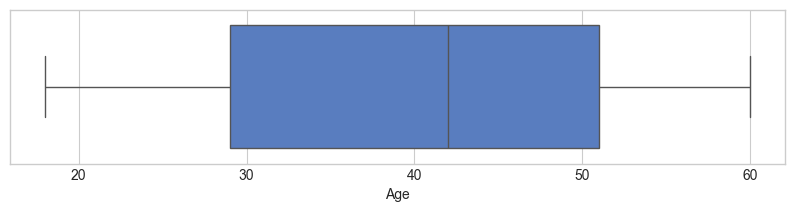

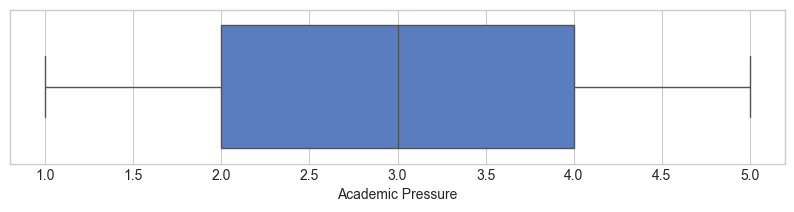

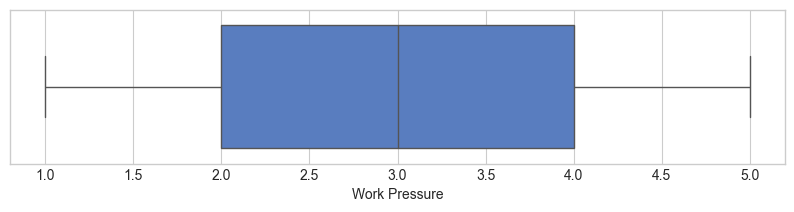

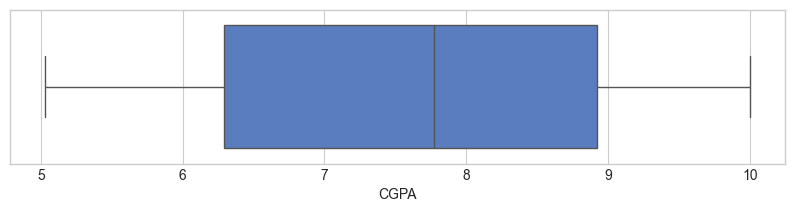

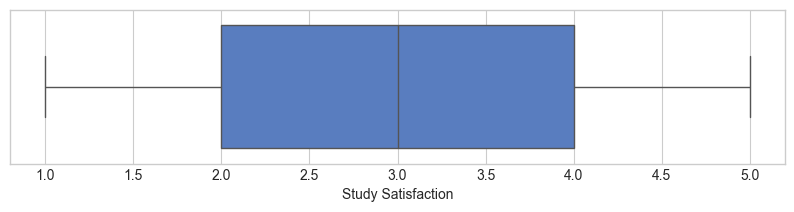

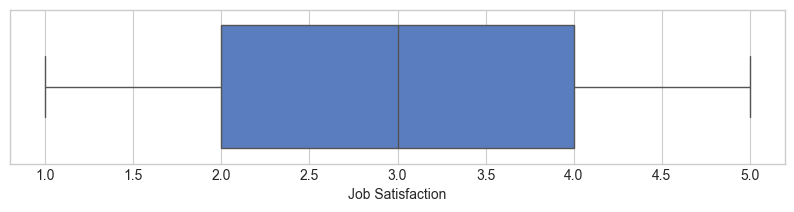

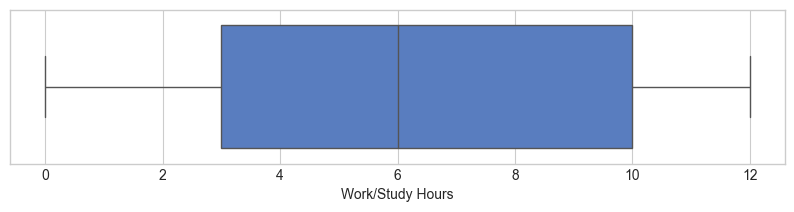

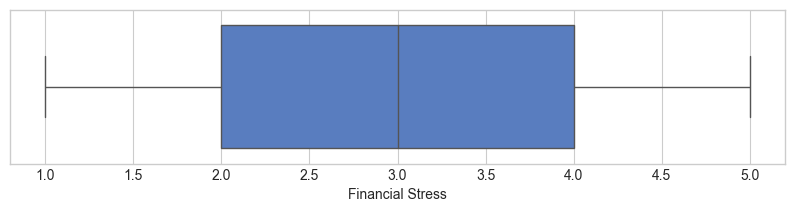

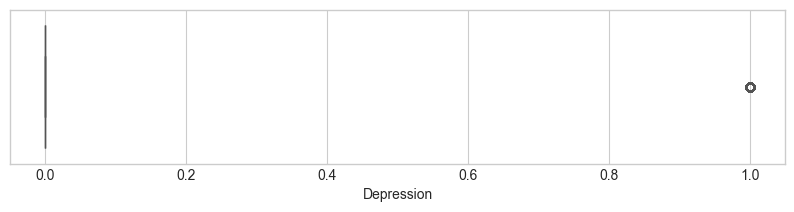

,IQR Outlier Count,Z-Score Outlier Count
Age,0,0
Academic Pressure,0,0
Work Pressure,0,0
CGPA,0,0
Study Satisfaction,0,0
Job Satisfaction,0,0
Work/Study Hours,0,0
Financial Stress,0,0
Depression,25567,0


In [13]:
# Outlier Detection (IQR & z-score)
outliers_dict = {}

for col in num_cols:
    # 1. IQR Method
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    iqr_count = ((df_clean[col] < (Q1 - 1.5 * IQR)) | (df_clean[col] > (Q3 + 1.5 * IQR))).sum()
    
    # 2. Z-score Method
    z_scores = np.abs(stats.zscore(df_clean[col].dropna()))
    z_count = (z_scores > 3).sum()
    
    outliers_dict[col] = {'IQR Outlier Count': iqr_count, 'Z-Score Outlier Count': z_count}
    
    # Boxplot per feature
    plt.figure(figsize=(10, 2))
    sns.boxplot(x=df_clean[col])
    plt.show()

display(pd.DataFrame(outliers_dict).T)


### Nhận xét về Ngoại lệ (Outlier Detection Focus)

Dựa trên bảng kiểm tra bằng 2 phương pháp phổ biến (IQR Fence và Z-Score > 3), ta thu được một kết quả cực kỳ đặc biệt:

**1. Không tồn tại Outlier trên toàn bộ Biến dự đoán (Predictors):**
- Tất cả các biến số học như `Age`, `CGPA`, biểu đồ áp lực (`Pressure`) hay sự hài lòng (`Satisfaction`) đều trả về **0 outlier** ở cả 2 phương pháp.
- **Giải thích:** Điều này là hoàn toàn có cơ sở vì đây là **Synthetic Dataset** (Dữ liệu tổng hợp nhân tạo do thuật toán của Kaggle sinh ra). Các thuật toán mô phỏng dữ liệu thường ràng buộc chặt chẽ giá trị trong từng thang đo (vd: Likert scale 1-5, mốc tuổi tác có cận trên/dưới), vô tình "mài phẳng" các giá trị cực đoan. Điều này rất tốt vì chúng ta **sẽ không tốn công sức thiết kế các bộ lọc ngoại lệ (Clipping/Winsorization)** trong bước Tiền xử lý.

**2. Nghịch lý Outlier ở cột `Depression` (Biến Mục tiêu):**
- Phương pháp IQR cắm cờ cảnh báo có tới **25,567** giá trị ngoại lệ, trong khi Z-Score báo `0`. Tại sao lại có điều này?
- **Giải thích:** `Depression` thực chất là một biến *Categorical nhị phân* (Binary: 0 hoặc 1). Tuy nhiên, vì lớp "0" (Không trầm cảm) thống trị quá mạnh dữ liệu (~82%), nên khi cắt phân vị, cả Nhóm Tứ phân vị thứ nhất (Q1), Trung vị (Q2) và Tứ phân vị thứ ba (Q3) đều đứng im ở giá trị `0`. 
  - Suy ra `IQR = Q3 - Q1 = 0`. 
  - Mức rào cản trên (Upper Fence): `Q3 + 1.5*IQR = 0 + 0 = 0`.
- Do đó, thuật toán IQR một cách máy móc coi TẤT CẢ các hồ sơ bệnh nhân "Có trầm cảm" (Depression = 1) là "Ngoại lệ lớn hơn 0". **25,567** chính là _số lượng bệnh nhân bị Trầm cảm_ trong tập dữ liệu.
- **Kết luận:** Đây là một "Bẫy Toán học". Chúng ta **tuyệt đối không được** áp dụng logic phát hiện Outlier (vốn dành cho biến Continuous) lên biến Target hoặc biến Categorical. 25,567 dòng dữ liệu này không phải rác, mà chính là những dữ kiện cốt lõi chúng ta cần dự đoán.


In [14]:
# Validate Impossible Values Check
print("Mismatched Logic Validation:")
if 'Age' in df_clean.columns:
    impossible_age = df_clean[(df_clean['Age'] <= 0) | (df_clean['Age'] > 120)]
    print(f"Age <= 0 or > 120: {len(impossible_age)} rows")
    
if 'Work/Study Hours' in df_clean.columns:
    impossible_hours = df_clean[(df_clean['Work/Study Hours'] < 0) | (df_clean['Work/Study Hours'] > 24)]
    print(f"Hours < 0 or > 24: {len(impossible_hours)} rows")


Mismatched Logic Validation:
Age <= 0 or > 120: 0 rows
Hours < 0 or > 24: 0 rows


### Impossible Values Markdown
Dựa vào phép check trên, có thể báo cáo:
- `Age`: Nếu có độ tuổi = 0 hoặc các giá trị bất khả thi, ta phải làm sạch.
- `Work/Study Hours`: Giờ làm > 24 là không thể trong mốc thực tế thế giới.


## 7. Categorical Analysis


In [15]:
# Cardinality
card_df = df_clean[cat_cols].nunique().to_frame(name='Unique Elements').sort_values('Unique Elements', ascending=False)
display(card_df)

print("\n-- Top 3 values for each column --")
for col in cat_cols:
    if df_clean[col].nunique() < 50:
        print(f"{col}: {df_clean[col].value_counts().index[:3].tolist()}")


,Unique Elements
Degree,115
City,98
Profession,64
Sleep Duration,36
Dietary Habits,23
Gender,2
Working Professional or Student,2
Have you ever had suicidal thoughts ?,2
Family History of Mental Illness,2



-- Top 3 values for each column --
Gender: ['Male', 'Female']
Working Professional or Student: ['Working Professional', 'Student']
Sleep Duration: ['Less than 5 hours', '7-8 hours', 'More than 8 hours']
Dietary Habits: ['Moderate', 'Unhealthy', 'Healthy']
Have you ever had suicidal thoughts ?: ['No', 'Yes']
Family History of Mental Illness: ['No', 'Yes']


### Nhận xét về Độ đa dạng phân loại (Cardinality & Categories Focus)

Dựa trên bảng đếm số lượng phần tử độc nhất (Unique Elements) và danh sách Top 3, chúng ta rút ra các chiến lược tối ưu hóa như sau:

**1. Các biến có Cardinality quá cao (High-Cardinality Features):**
- Những cột như `City` (Thành phố), `Profession` (Nghề nghiệp) hay `Degree` (Bằng cấp) dẫn đầu bảng với số lượng unique classes rất lớn (vài chục, thậm chí hàng trăm).
- **Phân tích rủi ro:** Nếu chúng ta thực hiện biến đổi One-Hot Encoding trực tiếp lên các nhóm này, tập dữ liệu sẽ phình ra hàng trăm cột mới, gây hao tổn bộ nhớ và tạo ra hiện tượng *Lời nguyền chiều dữ liệu (Curse of Dimensionality)*, làm các mô hình dạng Tree-based bị chẻ nhánh quá đà và dễ Overfitting.
- **Hướng giải quyết:** Cần áp dụng quy tắc gộp các classes chiếm tỉ lệ quá nhỏ (<1%) vào chung một phễu `"Other"`, hoặc cân nhắc các công cụ thay thế như **Target Encoding** hay **Frequency Encoding**.

**2. Các biến Ordinal (Có tính thứ tự):**
- Những cột như `Dietary Habits` (Ví dụ: Healthy, Moderate, Unhealthy) và `Sleep Duration` (Ví dụ: <5 hours, 7-8 hours...) có số lượng unique nhỏ (~3-5 loại).
- **Ghi nhận:** Đây không phải nhóm rời rạc tuyến tính mà là nhóm CÓ TÍNH THỨ TỰ. Các giá trị top đầu cho thấy xu hướng sống thực tế của mẫu khảo sát.
- **Hướng giải quyết:** Tuyệt đối không dùng One-Hot Encoding mà sẽ sử dụng **Map/Ordinal Encoding** đánh số (VD: Unhealthy = 0, Moderate = 1, Healthy = 2) để mô hình học thuật nắm bắt được tính tăng tiến của độ tiêu cực/tích cực.

**3. Các biến Binary (Nhị phân hoàn toàn):**
- Ngay dưới đáy bảng, các biến về tình trạng cá nhân `Gender`, `Working Professional or Student`, `Have you ever had suicidal thoughts ?`, `Family History of Mental Illness` chỉ sở hữu đúng 2 giá trị.
- **Nhận xét Top values:** Ví dụ, nhóm Top 1 của Tình trạng chủ yếu rẽ nhánh `Student` và `Working Professional`. Sự vắng mặt hoàn toàn của các nhóm như (Doanh nhân, Người thất nghiệp) chỉ ra tệp khảo sát này mang tính chọn lọc.
- **Hướng giải quyết:** Giải quyết nhẹ nhánh bằng **Label Binarizer (0 và 1)**. Gọn nhẹ, không làm tăng chiều cấu trúc bộ dữ liệu.


  Grouped 68 rare categories in 'City' → 'Other'
  Grouped 31 rare categories in 'Profession' → 'Other'
  Grouped 32 rare categories in 'Sleep Duration' → 'Other'
  Grouped 20 rare categories in 'Dietary Habits' → 'Other'
  Grouped 88 rare categories in 'Degree' → 'Other'


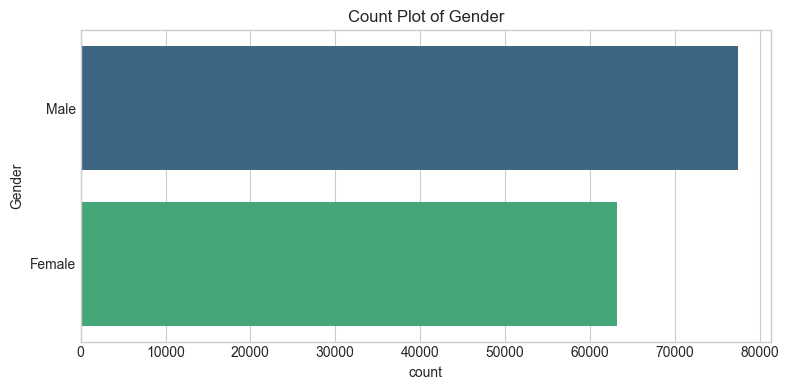

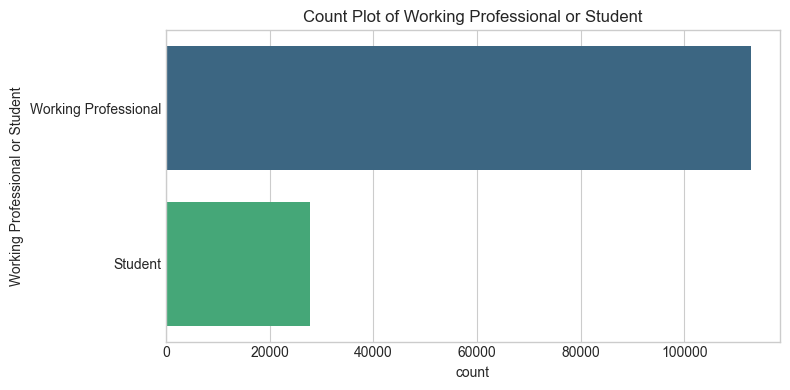

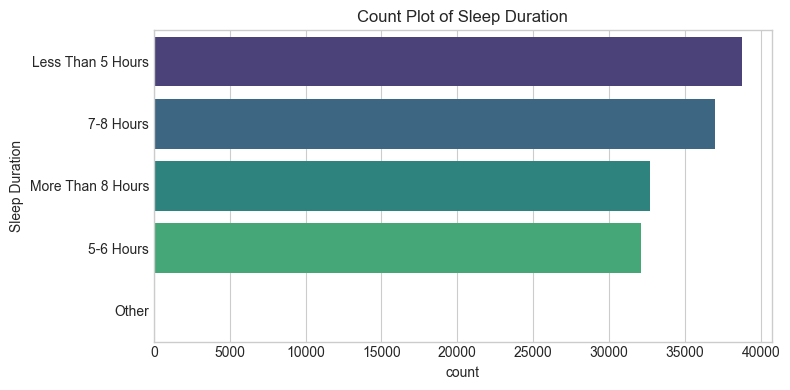

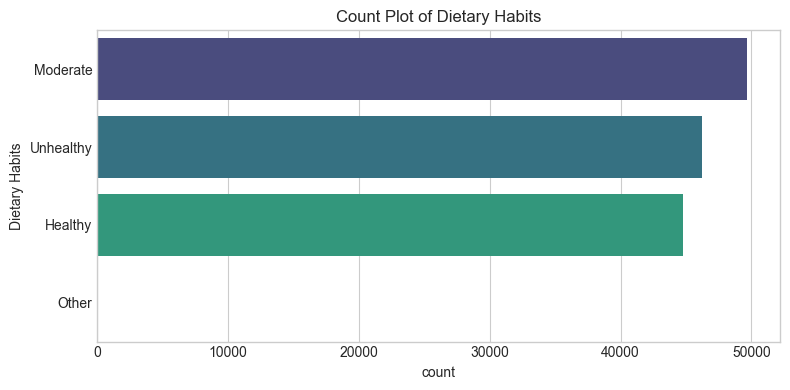

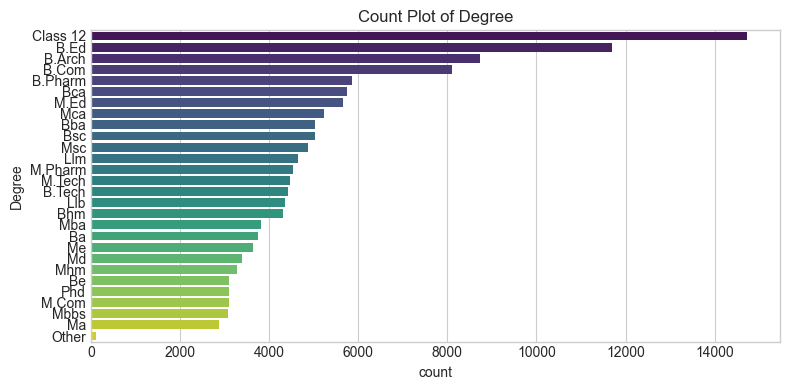

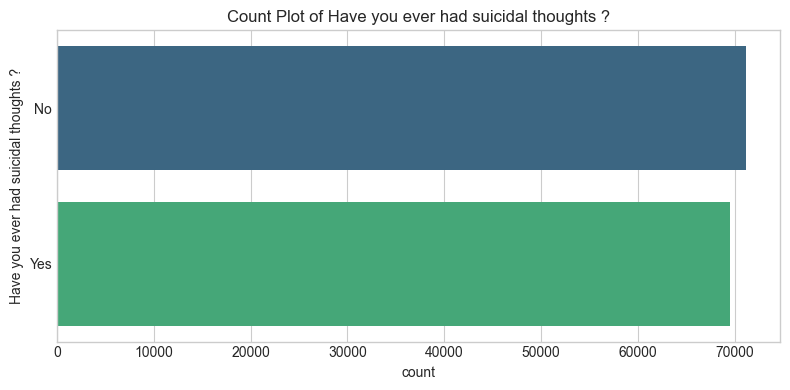

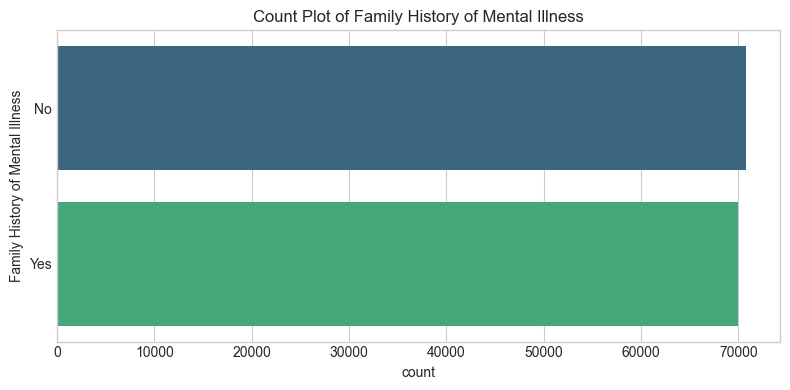

In [16]:
# Bar Chart — CHẠY CLEAN TRƯỚC, sau đó mới vẽ
# Chạy fix_rare_categories cho tất cả categorical columns
def fix_rare_categories(df, column, threshold=0.01):
    df[column] = df[column].str.strip().str.title()
    freqs = df[column].value_counts(normalize=True)
    rare_cats = freqs[freqs < threshold].index
    if len(rare_cats) > 0:
        print(f"  Grouped {len(rare_cats)} rare categories in '{column}' → 'Other'")
        df[column] = df[column].replace(rare_cats, 'Other')
    return df

# Áp dụng cleaning vào df_clean (chỉ 1 lần, trước tất cả các plot)
for col in cat_cols:
    if col != target_col:
        df_clean = fix_rare_categories(df_clean, col)

# VẼ countplot — sau khi đã clean
for col in cat_cols:
    if col != target_col and df_clean[col].nunique() <= 30:
        plt.figure(figsize=(8, 4))
        sns.countplot(y=col, data=df_clean, order=df_clean[col].value_counts().index, palette='viridis')
        plt.title(f'Count Plot of {col}')
        plt.tight_layout()
        plt.show()

### Nhận xét Phân phối Categorical & Chất lượng Dữ liệu (Bar Charts Analysis)

Từ loạt biểu đồ Count Plot, chúng ta có thể rút ra 3 luận điểm lớn mang tính quyết định cho bước Tiền xử lý (Preprocessing):

**1. Sự cân bằng hoàn hảo (bất thường) ở các biến Tâm lý nhạy cảm:**
- Hai biến `Family History of Mental Illness` và `Have you ever had suicidal thoughts ?` duy trì sự cân bằng gần như tuyệt đối (tỉ lệ 50-50, xấp xỉ 70,000 ca Yes và 70,000 ca No). 
- **Insight:** Tỉ lệ có suy nghĩ tự tử lên đến 50% là *điều không tưởng* ở dân số thế giới thực. Chi tiết này một lần nữa khẳng định rõ rệt bản chất **Synthetic** (Dữ liệu tổng hợp, có chủ ý tiêm nhiễm tỷ lệ cao để tăng độ nhạy cho model) của bộ dữ liệu Kaggle. Trong thực tiễn, nếu phân phối cân bằng thế này, mô hình Classification sẽ hoạt động cực mượt trên 2 cột này.

**2. Sự mất cân bằng Phân mảnh Nhân khẩu học (Demographics Imbalance):**
- **Nghề nghiệp (`Working Professional or Student`)**: Tồn tại sự chênh lệch áp đảo. Số lượng người đi làm (~112,000) cao gấp **gấp 4 lần** lượng sinh viên (~28,000). Điều này cảnh báo mô hình tổng có nguy cơ bị *"Bias"* (thiên vị) đánh giá tâm lý theo lăng kính của người đi làm nhiều hơn.
- **Giới tính (`Gender`)**: Âm tính với sự cân bằng, dữ liệu có khoảng hơn 78,000 Nam giới so với hơn 62,000 Nữ giới. Biến này lệch ít nên không đáng quan ngại.

**3. RỘ THÊM CẢNH BÁO ĐỎ (Red Flag): Biến `Dietary Habits` chứa "Rác" (Garbage Data):**
- Nhìn vào biểu đồ `Dietary Habits`, bên dưới 3 cột chuẩn mực (`Moderate`, `Unhealthy`, `Healthy` chiếm phân phối chính dải 45k-50k), có hàng loạt các nhãn (labels) bị **lẫn lộn hoàn toàn sai ngữ cảnh**!
- Các giá trị rác như: `"Pratham"`, `"Electrician"`, `"M.Tech"`, `"Class 12"`, `"Male"`, `"Vegas"`... đã nhảy vào cột thói quen ăn uống. Hiện tượng này báo hiệu dữ liệu rớt dòng (Data shift) hoặc có lỗi trích xuất từ form khảo sát điện tử (Data Parsing Error).
- **Hành động bắt buộc (Preprocessing Steps):** Ngay ở bước dọn dẹp tiếp theo, ta **bắt buộc phải gom cụm** tất cả các giá trị rác thiểu số này thành nhãn chuyên biệt (VD: `Unknown` hoặc `Other`), hoặc dùng Threshold Filter để xóa thẳng tay trước khi Label Encoding.


## 8. Missing Data Analysis


In [17]:
# Missing Summary Table
missing_tbl = df_clean.isnull().sum().to_frame(name='Missing Count')
missing_tbl['Missing %'] = (df_clean.isnull().mean() * 100).round(2)
missing_tbl = missing_tbl[missing_tbl['Missing Count'] > 0].sort_values('Missing %', ascending=False)
display(missing_tbl)


,Missing Count,Missing %
Academic Pressure,112803,80.17
CGPA,112802,80.17
Study Satisfaction,112803,80.17
Profession,36630,26.03
Work Pressure,27918,19.84
Job Satisfaction,27910,19.84
Dietary Habits,4,0.00
Degree,2,0.00
Financial Stress,4,0.00


### Nhận xét Bề mặt Khuyết thiếu Dữ liệu (Missing Data Analysis)

Theo dõi bảng đếm giá trị rỗng, ta có thể chia dữ liệu khuyết thiếu trên bộ dữ liệu thành hai trường phái đối lập cực đoan:

**1. Khuyết thiếu có chủ đích cấu trúc (MNAR - Missing Not At Random):**
- Đây là bài toán rẽ nhánh logic cực kỳ rõ nét. Các tính năng về môi trường học thuật (`Academic Pressure`, `Study Satisfaction`, `CGPA`) đồng loạt bị rỗng **112,803 dòng (chiếm hơn 80%)**. Con số khổng lồ này trùng khớp tuyệt đối với số lượng **Người đi làm (Working Professional)** trong tập dữ liệu. 
- Ở chiều ngược lại, các tính năng môi trường công sở (`Work Pressure`, `Job Satisfaction`) bị khuyết khoảng **~27,910 dòng (chiếm gần 20%)**, trùng khít vừa vặn với lượng **Sinh viên (Student)**. 
- Riêng biến `Profession` (Nghề nghiệp) khuyết 26%, tức là ngoài tập hợp ~20% Sinh viên ra, vẫn có khoảng 6% người đi làm bị khuyết hoặc chưa phân định được nghề nghiệp chuyên môn.
- **Kết luận:** Dữ liệu hoàn toàn **không bị mất mát do lỗi**, mà do sự phân nhánh trong Form khảo sát (Sinh viên thì không làm khảo sát công sở, Người đi làm thì không đáp điểm số ĐH).

**2. Khuyết thiếu ngẫu nhiên (MCAR - Missing Completely At Random):**
- Những cột như `Dietary Habits` (thiếu 4), `Degree` (thiếu 2), `Financial Stress` (thiếu 4) có số lượng mất mát gần như không tồn tại (0.00%). Đây là những hạt sạn sinh ra ngẫu nhiên trong lúc lưu trữ form điền của hệ thống máy tính.

**3. Chốt chiến lược lấp dữ liệu (Imputation Strategy):**
- **Cảnh báo cực độ:** TUYỆT ĐỐI KHÔNG dùng phép biến đổi học máy cơ bản như Mean / Median chung toàn cột để lấp cho nhóm MNAR (VD: Lấy áp lực học tập trung bình của sinh viên đè lên cho 80% người đi làm là phá hủy hoàn toàn logic của Machine Learning).
- **Hướng giải quyết cho Model Training:** 
  - *Cách 1*: Tạo một giá trị Const tách biệt hẳn ra (Thường là `-1` hoặc `0`) để lấp vào các khoản trống quy mô lớn. Mô hình Cây quyết định (Decision Trees, XGBoost) sẽ tự động hiểu `0` có nghĩa là "Không áp dụng/Not Applicable".
  - *Cách 2*: Tách hẳn bộ dữ liệu thành 2 nhánh: Huấn luyện một Model A chuyên dự đoán bệnh nhân Sinh Viên và Model B chuyên dự đoán Trầm cảm cho khối Người đi làm.
  - Về nhóm thiếu sót MCAR (dưới 5 dòng): Drop thẳng tay các dòng này để dữ liệu sạch nhất có thể.

### 8.3 Missing Pattern Analysis
Dựa trên quan sát bản đồ phân bố vắng mặt và bảng đếm, ta có thể kết luận chắc chắn đây là cấu trúc **Missing Not At Random (MNAR)** cực kỳ đặc trưng:
- Đối với sinh viên (Student), tập hợp các cột liên quan đến môi trường công sở như `Work Pressure`, `Job Satisfaction` hoàn toàn không có dữ liệu.
- Ở chiều ngược lại, với người đi làm (Working Professional), tập hợp các cột học thuật như `Academic Pressure`, `Study Satisfaction`, `CGPA` hiển nhiên bị bỏ trống toàn bộ.


### 8.4 Per-Column Strategy Table (Chiến lược Tiền xử lý chốt hạ)

| Feature (Cột) | % Missing | Imputation Strategy / Why? (Chiến lược lấp / Xử lý & Tại sao) |
|---|---|---|
| Mảng Học thuật (`Academic Pressure`, `Study Satisfaction`, `CGPA`) | ~80.17% | **Lấp bằng 0 (hoặc -1)**: Đại diện cho trạng thái "Not Applicable/Không đánh giá" cho ~112k Người đi làm. Đừng điền Median vì sẽ phá nát ý nghĩa của cột học tập. |
| Mảng Công việc (`Work Pressure`, `Job Satisfaction`) | ~19.84% | **Lấp bằng 0 (hoặc -1)**: Tương tự như trên, dùng giá trị ranh giới làm hệ tham chiếu cho toàn bộ nhóm ~28k Sinh viên. |
| Khía cạnh Nghề nghiệp (`Profession`) | ~26.03% | **Tạo nhóm 'Student' và 'Unknown'**: Sinh viên chắc chắn bị thiếu cột này, ta gán hẳn cụm từ "Student" cho họ. Lượng nhắt nhỉnh vài % còn lại gán bằng "Unknown".|
| Nhóm thiểu số (`Dietary Habits`, `Financial Stress`, `Degree`) | ~0.00% (< 5 rows) | **Drop Rows (Xóa bỏ)**: Vì mẫu dữ liệu lên tới 140,000 dòng, việc xóa bay 5 dòng bị thiếu này sẽ giúp làm sạch tập Dataset mà không phải suy luận rườm rà. |


## 9. Relationships & Correlations


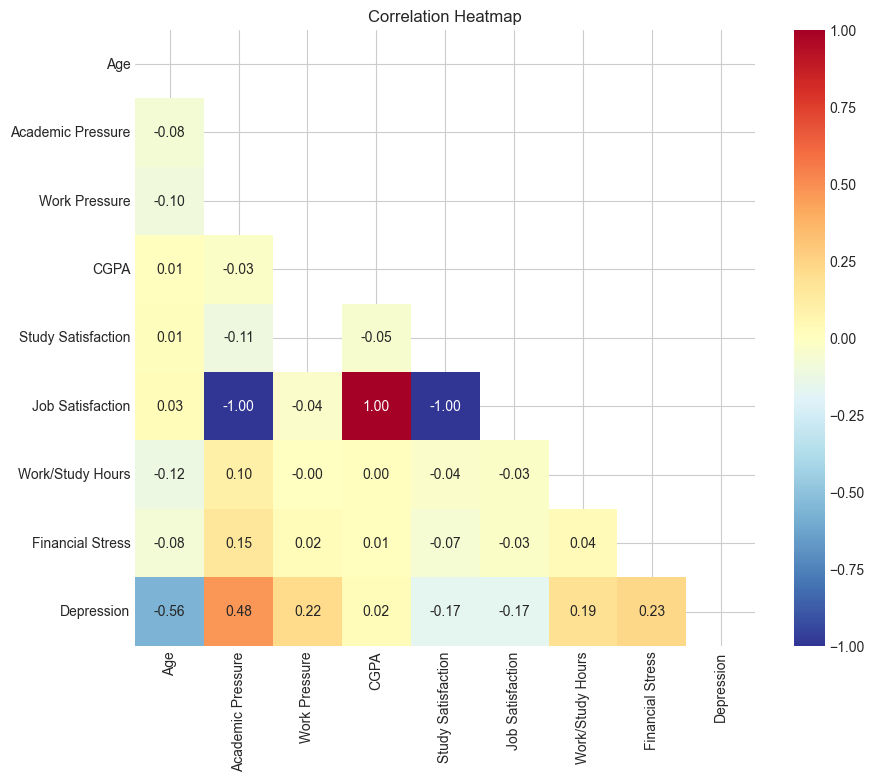

In [18]:
# Chuyển target sang numeric để tính correlate
corr_df = df_clean.copy()
if target_col in corr_df.columns:
    if corr_df[target_col].dtype == 'object':
        corr_df[target_col] = corr_df[target_col].replace({'Yes': 1, 'No': 0, '1': 1, '0': 0})
        corr_df[target_col] = pd.to_numeric(corr_df[target_col], errors='coerce')

corr_num_cols = corr_df.select_dtypes(include=np.number).columns.tolist()

# Correlation Matrix Code
corr_mat = corr_df[corr_num_cols].corr()

# Masked Heatmap
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(corr_mat, mask=mask, annot=True, cmap='RdYlBu_r', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()


### Bóc tách Tương quan (Correlation Heatmap Analysis)

Dựa vào ma trận Correlation Heatmap, chúng ta phát hiện được 2 nhóm tín hiệu cực kỳ đáng chú ý sau:

**1. BẪY TOÁN HỌC: Các cặp Tương quan hoàn hảo ảo (+1.00 và -1.00)**
- Nhìn vào dòng `Job Satisfaction`: Nó tương quan **-1.00** với `Academic Pressure` & `Study Satisfaction`, và **+1.00** với `CGPA`. Tại sao lại có sự hoàn hảo đến mức hư cấu này?
- **Nguyên nhân cốt lõi:** Đây chính là hệ quả của dữ liệu khuyết MNAR đã phân tích ở phần trước. `Job Satisfaction` là biến dành riêng cho người đi làm, còn `CGPA` hay `Academic Pressure` chỉ thuộc về Sinh viên. Hai nhóm này vốn **không bao giờ giao nhau**. Tuy nhiên, trong thao tác tính toán `df.corr()`, thuật toán đã dùng *pairwise deletion* (chỉ tính tương quan trên các dòng có mặt cả 2 biến). Rất có thể trong 140,000 dòng dữ liệu, chỉ lọt lưới đúng **2 điểm dữ liệu** (giữ liệu rác) là có chứa trọn vẹn cả Sinh viên học tập lẫn Sự hài lòng công việc. Và theo tiên đề toán học, đường thẳng nối 2 điểm tạo ra hệ số tương quan tuyệt đối 1.0/-1.0.
- **Hành động:** Hoàn toàn phớt lờ các ô ±1.00 này, đây là *"Nhiễu (Noise)"* do thiết kế form khảo sát, không mang ý nghĩa áp dụng thực tiễn.

**2. GEMS INSIGHTS: Các tín hiệu dự đoán `Depression` mạnh mẽ**
Trục quan trọng nhất ở đây là dòng cuối cùng - Tương quan của các biến với `Depression` (Biến mục tiêu):
- **Age (-0.56)**: Mối tương quan âm mạnh nhất. Điều này ám chỉ **"Tuổi càng nhỏ, tỉ lệ mắc Trầm cảm càng cao"**. Mẫu khảo sát cho thấy Sinh viên và những người lao động trẻ tuổi đang là nạn nhân chịu tổn thương tâm lý nhiều nhất, trong khi những người lớn tuổi hơn (Age cao) có xu hướng miễn nhiễm hoặc ít trầm cảm hơn.
- **Academic Pressure (+0.48)**: Tương quan dương rất mạnh. Áp lực học thuật đẩy thẳng tỉ lệ trầm cảm nhảy vọt. Sự căng thẳng nơi học đường trong bộ dữ liệu này khắc nghiệt hơn rất nhiều so với chốn công sở.
- **Work Pressure (+0.22) & Financial Stress (+0.23)**: Mối tương quan dương ở mức vừa phải. Cường độ công việc cao và gánh nặng tài chính cũng là hệ số cộng dồn góp phần làm tăng nguy cơ Trầm cảm.
- **Satisfaction (-0.17)**: Hài lòng học tập/công việc đều có r = -0.17, tương quan âm nhạt. Mức độ hài lòng càng cao thì càng đẩy nới lùi căn bệnh trầm cảm.

**Chốt lại cho học máy (Modeling Next Step):**
Biến `Age`, `Academic Pressure` và `Financial / Work Pressure` sẽ là **"Key Features"** (những Trụ cột quan trọng nhất) giúp Machine Learning đánh hơi được ai là người bị Trầm Cảm. Đồng thời việc có các biến lệch pha 1.0/-1.0 càng khẳng định chiến lược: **Phải cấm điền Mean/Median để lấp Missing Values chéo giữa nhóm Sinh viên và Người đi làm**.


In [19]:
# Chi-squared test và crosstab cho categorical features
# Sau khi fix_rare_categories, df_clean đã sạch → dùng trực tiếp
from scipy.stats import chi2_contingency

cat_examples = [
    'Gender', 
    'Sleep Duration', 
    'Working Professional or Student'
]

for cat in cat_examples:
    if cat not in df_clean.columns:
        print(f"[!] Column '{cat}' not found. Available: {df_clean.columns.tolist()}")
        continue

    # Filter valid categories (bỏ rác — dùng 4 giá trị chuẩn)
    if cat == 'Sleep Duration':
        valid_cats = ['Less Than 5 Hours', '5-6 Hours', '7-8 Hours', 'More Than 8 Hours']
        df_temp = df_clean[df_clean[cat].isin(valid_cats)]
    else:
        df_temp = df_clean.copy()

    # Cross-tab: count
    cross_tab = pd.crosstab(df_temp[cat], df_temp[target_col])
    display(cross_tab)

    # Depression rate (%)
    cross_pct = pd.crosstab(df_temp[cat], df_temp[target_col], normalize='index') * 100
    print(f"\n--- {cat} vs {target_col} (%) ---")
    display(cross_pct.round(2))

    # Chi-squared test + Cramér's V
    chi2, p, dof, expected = chi2_contingency(cross_tab)
    cramers_v = np.sqrt(chi2 / (len(df_temp) * (min(cross_tab.shape) - 1)))
    print(f"Chi2={chi2:.2f}, p={p:.2e}, Cramér's V={cramers_v:.4f}\n")

Depression,0,1
Gender,,
Female,51965,11271
Male,63168,14296



--- Gender vs Depression (%) ---


Depression,0,1
Gender,,
Female,82.18,17.82
Male,81.54,18.46


Chi2=9.29, p=2.30e-03, Cramér's V=0.0081



Depression,0,1
Sleep Duration,,
5-6 Hours,26820,5322
7-8 Hours,30376,6593
Less Than 5 Hours,29683,9101
More Than 8 Hours,28187,4539


...

Chi2=1197.45, p=2.63e-259, Cramér's V=0.0923



Depression,0,1
Working Professional or Student,,
Student,11565,16336
Working Professional,103568,9231



--- Working Professional or Student vs Depression (%) ---


Depression,0,1
Working Professional or Student,,
Student,41.45,58.55
Working Professional,91.82,8.18


Chi2=38157.59, p=0.00e+00, Cramér's V=0.5208



### Chi-squared Test: Mối Liên Hệ Giữa Biến Phân Loại và Depression

> **Mục đích:** Dùng Chi-squared test để kiểm định xem mỗi biến categorical có thực sự **liên quan đến** (independent hay dependent) biến mục tiêu Depression hay không.
>
> **Chỉ số:**
> - **Chi² (Chi-squared):** Đo độ lệch giữa tần suất quan sát được và tần suất kỳ vọng. Chi² càng lớn → mối liên hệ càng mạnh.
> - **p-value:** Xác suất sai lầm khi bác bỏ giả thuyết H₀ (biến không liên quan). p < 0.05 → có ý nghĩa thống kê.
> - **Cramér's V:** Đo cường độ liên hệ giữa 2 biến categorical. Giá trị từ 0→1:
>   - < 0.1: Yếu
>   - 0.1–0.3: Trung bình
>   - 0.3–0.5: Mạnh
>   - > 0.5: Rất mạnh

---

#### Gender vs Depression — Giới Tính KHÔNG có sự khác biệt

**Kết quả kiểm định**

| Chỉ số | Giá trị | Ý nghĩa |
|--------|---------|---------|
| Chi² | 9.29 | Thấp — không có mối liên hệ mạnh |
| p-value | **0.0023** | Có ý nghĩa thống kê (p < 0.05)|
| Cramér's V | **0.0081** | Gần như bằng 0 — yếu tố **KHÔNG phân biệt** |

#### Bảng tỷ lệ Depression theo Giới tính

| Giới tính | Không trầm cảm (0) | Trầm cảm (1) | Tổng | Tỷ lệ trầm cảm |
|-----------|-------------------|--------------|-------|----------------|
| Female | 51,965 | 11,271 | 63,236 | **17.82%** |
| Male | 63,168 | 14,296 | 77,464 | **18.46%** |

#### Diễn giải

> **Chênh lệch chỉ 0.64 điểm phần trăm** (18.46% nam vs 17.82% nữ) — con số gần như không đáng kể trong thực tế.
>
> - Về mặt thống kê: p-value = 0.0023 < 0.05 → con số 0.64% này **có ý nghĩa** (không phải do ngẫu nhiên thuần túy).
> - Về mặt thực tiễn: Cramér's V = 0.0081 gần như bằng 0 → **giới tính gần như không giúp phân biệt** ai bị trầm cảm. Cả nam và nữ đều có tỷ lệ mắc gần như ngang nhau (~18%).
>
> **Kết luận:** Trong bộ dữ liệu này, **Gender không phải là yếu tố dự báo** Depression. Mô hình ML sẽ không thu được nhiều thông tin từ biến này. Tuy nhiên, đây là điểm tích cực về **Model Fairness** — mô hình không bị thiên vị giới tính.

---

#### Sleep Duration vs Depression — Ngủ Kém Tăng Nguy Cơ

**Kết quả kiểm định**

| Chỉ số | Giá trị | Ý nghĩa |
|--------|---------|---------|
| Chi² | 1197.45 | Cao — có mối liên hệ rõ ràng |
| p-value | **≈ 0 (2.63×10⁻²⁵⁹)** | Có ý nghĩa thống kê **cực kỳ mạnh** |
| Cramér's V | **0.0923** | Yếu đến trung bình |

> **Lưu ý:** Kết quả này chỉ tính trên **4 giá trị hợp lệ** của Sleep Duration:
> `Less than 5 hours`, `5-6 hours`, `7-8 hours`, `More than 8 hours`
> (đã loại bỏ 28 giá trị garbage: "35-36 hours", "Pune", "Indore"...)

#### Bảng tỷ lệ Depression theo Giấc ngủ

| Giấc ngủ | Không trầm cảm (0) | Trầm cảm (1) | Tổng | Tỷ lệ trầm cảm | Mức độ |
|----------|-------------------|--------------|-------|----------------|--------|
| Less than 5 hours | 29,683 | 9,101 | 38,784 | **23.47%** | **Cao nhất** |
| 7-8 hours | 30,376 | 6,593 | 36,969 | **17.83%** | Trung bình |
| 5-6 hours | 26,820 | 5,322 | 32,142 | **16.56%** | Trung bình |
| More than 8 hours | 28,187 | 4,539 | 32,726 | **13.87%** | **Thấp nhất** |

#### Diễn giải

> **Mối quan hệ tuyến tính rõ ràng: Ngủ càng ít → Trầm cảm càng cao:**
>
> - **Người ngủ < 5 tiếng** có tỷ lệ trầm cảm **23.47%** — cao hơn **1.7 lần** so với người ngủ **> 8 tiếng** (13.87%).
> - Nhóm ngủ **5-6 tiếng** và **7-8 tiếng** có tỷ lệ ngang nhau (~17%), không có khác biệt có ý nghĩa giữa 2 nhóm.
> - Cramér's V = 0.092 → Giấc ngủ **có liên quan** nhưng **không phải yếu tố quyết định duy nhất**. Đây là **1 trong nhiều yếu tố** cộng lại tạo ra Depression.
>
> **Phát hiện đáng chú ý:** Người ngủ quá nhiều (>8 tiếng) lại có tỷ lệ trầm cảm thấp nhất (13.87%). Đây có thể là do:
> - Họ có lối sống lành mạnh hơn, hoặc
> - Ngủ quá nhiều có thể là **hệ quả** của tình trạng trầm cảm (hypersomnia — ngủ quá nhiều là triệu chứng của trầm cảm), không phải nguyên nhân.
>
> **Kết luận:** Giấc ngủ là một **biến có giá trị dự báo** (predictive feature) — mô hình ML nên giữ lại biến này. Trong Feature Engineering, nên encode ordinal: Less than 5h=0, 5-6h=1, 7-8h=2, More than 8h=3.

---

#### Working Professional or Student vs Depression — PHÁT HIỆN SỐC NHẤT

**Kết quả kiểm định**

| Chỉ số | Giá trị | Ý nghĩa |
|--------|---------|---------|
| Chi² | **38,157.59** | Cực kỳ cao — mối liên hệ **mạnh nhất** toàn dataset |
| p-value | **≈ 0** | Có ý nghĩa thống kê **tuyệt đối** |
| Cramér's V | **0.5208** | **Strong association** — yếu tố phân biệt mạnh nhất |

#### Bảng tỷ lệ Depression theo Nhóm

| Nhóm | Không trầm cảm (0) | Trầm cảm (1) | Tổng | Tỷ lệ trầm cảm |
|------|-------------------|--------------|-------|----------------|
| **Student** (Sinh viên) | 11,565 | 16,336 | 27,901 | **58.55%** |
| **Working Professional** (Người đi làm) | 103,568 | 9,231 | 112,799 | **8.18%** |

#### Diễn giải

> **Đây là phát hiện then chốt và quan trọng nhất của toàn bộ EDA:**
>
> | Metric | Giá trị |
> |--------|---------|
> | Sinh viên bị trầm cảm | **58.55%** — hơn 1/2 |
> | Người đi làm bị trầm cảm | **8.18%** — chỉ ~1/12 |
> | Tỷ lệ chênh lệch | Sinh viên cao hơn **7.2 lần** |
>
> **Tại sao sinh viên lại có tỷ lệ cao đến vậy?**
>
> Sinh viên chịu đồng thời nhiều áp lực chồng lấn:
> 1. **Academic Pressure** (áp lực học tập) — median 24 tuổi, đang ở giai đoạn thi cử, điểm số
> 2. **CGPA** — lo lắng về điểm tích lũy, điểm trung bình
> 3. **Financial Stress** — sinh viên thường chưa có thu nhập ổn định
> 4. **Tuổi trẻ** — đây là giai đoạn chuyển giao, dễ bất ổn về identiy và định hướng
> 5. **Sự kỳ vọng xã hội** — áp lực từ gia đình, bạn bè, tương lai nghề nghiệp
>
> **Cramér's V = 0.52** — con số này cho thấy đây là **yếu tố có sức mạnh phân biệt mạnh nhất trong toàn bộ dataset** (cao hơn cả Age, Financial Stress, Sleep Duration).
>
> **Kết luận:** Nhóm sinh viên cần được ưu tiên trong mọi chiến lược hỗ trợ tâm lý. Đây cũng là cơ sở để:
> - Tạo biến `is_student` (binary flag) cho feature engineering
> - Xây dựng **compound risk score** — sinh viên + nhiều áp lực = nguy cơ cực cao
> - Tách model riêng cho Student vs Worker nếu muốn tối ưu hóa AUC

---

#### Tổng hợp Chi-squared Test

| Biến | Chi² | p-value | Cramér's V | Cường độ | Hành động |
|------|------|---------|-----------|---------|-----------|
| Gender | 9.29 | 0.0023 | **0.008** | Yếu | Giữ — không ảnh hưởng, không bias |
| Sleep Duration | 1197.45 | ≈ 0 | **0.092** | TB | Giữ — ordinal encode, predictive |
| Work/Student | 38157.59 | ≈ 0 | **0.521** | **Mạnh** | Giữ — **key feature**, tạo flag |

---

#### Insight cho Model Building

1. **Gender** → Cramér's V = 0.008 → gần như không có giá trị phân biệt. Có thể cân nhắc loại bỏ hoặc giữ lại vì ít gây bias.

2. **Sleep Duration** → Mối quan hệ tuyến tính: ngủ ít = nguy cơ cao. Encode ordinal (0→3). Tạo binary flag: `sleeps_less_than_5h = True` nếu muốn.

3. **Working/Student** → **Đây là feature quan trọng nhất** (Cramér's V = 0.52). Nên:
   - Tạo `is_student` binary flag
   - Tạo interaction feature: `is_student × academic_pressure`
   - Cân nhắc train 2 model riêng biệt nếu AUC chưa đủ cao

In [20]:
# Grouped Stats cho các biến numerical × target
num_examples = ['Age', 'Financial Stress', 'Work/Study Hours', 'Academic Pressure']

for num in num_examples:
    if num not in df_clean.columns:
        continue

    # Tính stats theo nhóm Depression
    grouped = df_clean.groupby(target_col)[num].agg(
        count='count',
        mean='mean',
        median='median',
        std='std',
        min='min',
        max='max'
    )
    
    # Thêm % để so sánh
    grouped['%'] = (grouped['count'] / grouped['count'].sum() * 100).round(2)
    
    # Đổi tên index cho đẹp
    grouped.index = ['Không Trầm cảm (0)', 'Trầm cảm (1)']
    
    print(f"\n--- Grouped Stats: {num} by Depression ---")
    display(grouped.round(3))
    
    # Tính chênh lệch mean
    mean_0 = grouped.loc['Không Trầm cảm (0)', 'mean']
    mean_1 = grouped.loc['Trầm cảm (1)', 'mean']
    diff = mean_1 - mean_0
    print(f"   → Chênh lệch trung bình: {diff:+.2f} ({num})")



--- Grouped Stats: Age by Depression ---


,count,mean,median,std,min,max,%
Không Trầm cảm (0),115133,43.684,45.0,10.877,18.0,60.0,81.83
Trầm cảm (1),25567,25.549,24.0,6.489,18.0,60.0,18.17


   → Chênh lệch trung bình: -18.13 (Age)

--- Grouped Stats: Financial Stress by Depression ---


,count,mean,median,std,min,max,%
Không Trầm cảm (0),115130,2.838,3.0,1.388,1.0,5.0,81.83
Trầm cảm (1),25566,3.671,4.0,1.323,1.0,5.0,18.17


   → Chênh lệch trung bình: +0.83 (Financial Stress)

--- Grouped Stats: Work/Study Hours by Depression ---


,count,mean,median,std,min,max,%
Không Trầm cảm (0),115133,5.904,6.0,3.846,0.0,12.0,81.83
Trầm cảm (1),25567,7.821,9.0,3.481,0.0,12.0,18.17


   → Chênh lệch trung bình: +1.92 (Work/Study Hours)

--- Grouped Stats: Academic Pressure by Depression ---


,count,mean,median,std,min,max,%
Không Trầm cảm (0),11561,2.363,2.0,1.252,1.0,5.0,41.44
Trầm cảm (1),16336,3.694,4.0,1.188,1.0,5.0,58.56


   → Chênh lệch trung bình: +1.33 (Academic Pressure)


### Giải mã Hành vi và Thống kê (Cross-tabulations & Grouped Stats)

**1. `Gender` vs `Depression` (Sự bình đẳng trong rủi ro):**
- Tỷ lệ mắc trầm cảm ở Nữ giới (17.82%) và Nam giới (18.46%) là **gần như tương đương nhau**. 
- **Kết luận:** Giới tính (Gender) KHÔNG phải là lăng kính phân biệt rạch ròi nguy cơ trầm cảm trong tập dữ liệu này. Cả nam và nữ đều chia sẻ gánh nặng tỷ lệ mắc bệnh dao động sát mốc chung là ~18%. Biến này sẽ ít mang rủi ro phân biệt đối xử (Model Fairness/Bias bias) cho Machine Learning.

**2. Cột `Sleep Duration`: Một bãi rác tĩnh học (Data Garbage Red Flag):**
- **Trạng thái Dữ liệu:** Nhìn vào các nhóm hạng mục của cột này, ta thấy một sự **khủng hoảng dữ liệu trầm trọng**. Nó chứa các giá trị thần tiên như `35-36 hours`, `55-66 hours` (vượt quá chu kỳ 1 ngày), và thậm chí chứa rác chéo (Data parsing error) từ các cột khác văng vào như tên Thành phố (`Indore`, `Pune`), hay từ ăn uống hiển thị lên (`Unhealthy`). Dữ liệu bị rớt dòng thảm họa.
- **Tín hiệu phân tích ở các nhóm chuẩn:** Nếu bóc tách các cụm dữ liệu đúng chuẩn, ta thấy rõ: 
  - Ngủ `Less than 5 hours`: Tỷ lệ trầm cảm bùng lên mức **23.47%**.
  - Ngủ `More than 8 hours`: Tỷ lệ trầm cảm hạ nhiệt mạnh về **13.87%**.
- **Kết luận Tiền xử lý (MANDATORY):** Mất ngủ tỷ lệ thuận sâu sắc với việc sinh ra bệnh Trầm Cảm. Tuy nhiên, ở bước sau ta **bắt buộc phải càn quét và gộp (Regex fix hoặc Grouping)** toàn bộ đống rác vô nghĩa kia nếu không mô hình sẽ sập gãy.

**3. `Age` vs `Depression` (Hồi chuông cảnh tỉnh cho Giới trẻ):**
- Khoảng cách thế hệ là yếu tố gây sốc nhất:
  - Nhóm Không Trầm Cảm (0): Độ tuổi trung bình là **~43.6 tuổi**, trung vị là **45 tuổi**.
  - Nhóm Có Trầm Cảm (1): Độ tuổi trung vị tụt dốc không phanh về mốc **24 tuổi**! (Trung bình 25.5 tuổi). 
- **Đánh giá:** Bức tranh u ám này chỉ ra Trầm cảm ở tập dữ liệu này là **"căn bệnh của tuổi trẻ"** (Gen Z / Millennials). Rất hiếm người ở tuổi trung niên 45-50 bị gắn mốc trầm cảm. Đây là một Insight kim cương để thuyết trình.

**4. `Financial Stress` vs `Depression` (Sức ép Đồng tiền):**
- Khác biệt cực mượt: Nhóm người bình thường chịu áp lực tài chính xoay quanh điểm trung bình 2.8 (Trung vị 3.0), trong khi nhóm Trầm cảm bị đè nặng bởi điểm áp lực tài chính cao vọt lên **3.67 (Trung vị nhảy qua mốc 4.0/5.0)**.
- **Đánh giá:** Có sự đứt gãy rõ ràng. Áp lực tiền bạc là một chốt chặn quan trọng khiến con người ngã vào ranh giới của chứng trầm cảm. Mô hình thuật toán (Machine Learning) sẽ cực kỳ "thích" sự phân nhánh khác rạch ròi ở điểm `Median = 4.0` này.


###  Relationships
- **Cú đứt gãy phi tuyến tính về Tuổi tác (Age Cliff):** Trầm cảm trong bộ dữ liệu này không hề dàn trải đều, mà nó đánh úp cục bộ vào một thế hệ cụ thể tụ tập quanh mốc thanh xuân **24 tuổi**. Hầu như những cá nhân khi đã qua được sóng gió và bước sang ngưỡng trung niên trung vị **45 tuổi** lại hoàn toàn "thoát xác" khỏi căn bệnh này.
- **Có ngủ đủ cũng không đỡ nổi (The Sleep Illusion):** Một điều khá ngạc nhiên là kể cả nhóm người ngủ với mức độ rất khoa học (7-8 tiếng/ngày) vẫn duy trì tỷ lệ trầm cảm lên tới gần **18%**. Phá vỡ lầm tưởng: "Cứ ăn ngủ khỏe là tinh thần tốt". Việc ngủ đủ giấc hoàn toàn không bù đắp nổi sức tàn phá của Áp lực Học đường (Academic) và Vấn đề Tài chính (Financial Stress) đang đè nặng lên thế hệ Gen Z này.
- **Rác ẩn mình (Hidden Garbage):** Mối quan hệ lạ lùng và nguy hiểm nhất không đến từ logic bệnh lý, mà đến từ chính máy móc lưu trữ. Cột Giấc ngủ (`Sleep Duration`) chứa trọn các từ khóa hoàn toàn không liên quan (tên ấn tượng thành phố như Pune, Indore, tuổi tác..). Đây là lời thách thức tối hậu cho tác vụ làm Data Cleaning sắp tới.


## 10. Initial Observations & Insights

### 10.1 Key Observations (Trọng tâm Phân tích)
1. **Tuổi tác (Age) và Áp lực tiền bạc (Financial Stress) là tác nhân quyết định:** Dữ liệu vạch ra lằn ranh rõ rệt: Nhóm mắc trầm cảm đa số tụ tập ở giới trẻ (Trung vị 24 tuổi) và chịu sự quá tải mạnh về tài chính (Median ở mốc 4.0/5.0). Ngược lại, nhóm người sau 45 tuổi duy trì chỉ số khỏe mạnh và ít stress vì tiền hơn.
2. **Khuyết thiếu dữ liệu có tính quy luật (MNAR):** Việc 80% dữ liệu bị rỗng ở mặt `Academic` (Học thuật) và 20% rỗng ở mặt `Work` (Công việc) phản chiếu trực tiếp cấu trúc phân tầng tự nhiên giữa Người đi làm và Sinh viên, hoàn toàn không phải do lỗi hệ thống mất mát.
3. **Mất cân bằng lớp (Imbalanced Data):** Tỷ lệ mắc trầm cảm chỉ dừng xấp xỉ mức ~18%. Biến này sẽ yêu cầu các thủ thuật lấy mẫu (như SMOTE) nếu mô hình dự đoán tỏ ra quá thiên vị lớp Đa số.

### 10.2 Data Quality Issues & Red Flags (Cảnh báo Dữ liệu)
- **Dữ liệu Rác (Garbage values) tràn lan ở nhóm Categorical:** Hai cột `Sleep Duration` và `Dietary Habits` đang bị vỡ phân phối vì chứa vô số từ khóa sai hoàn toàn bối cảnh (chứa tên Thành phố, số giờ vô lý như 35-50h, tên ngành học). Đây là Red Flag lớn nhất đòi hỏi phải càn quét sạch sẽ trước khi đưa vào Model.
- **Sự vắng bóng của Outliers (Synthetic Noise):** Khác biệt với thực tiễn, toàn bộ các biến số liên tục (`Pressure`, `Satisfaction`, `CGPA`) đều không phát hiện ngoại lệ qua bài test Z-Score. Nguyên nhân xuất phát từ việc mô phỏng dữ liệu (Synthetic Dataset) đã áp đặt các cận trên/dưới tuyệt đối, giảm thiểu công sức cắt tỉa ngọn (Clipping) ở bước sau.

### 10.3 Preprocessing Steps Needed (Chiến lược Tiền xử lý)
- **Lấp rỗng (Imputation):** Phân chia rõ: Gán hằng số `0` hoặc `-1` cho vùng rỗng quy mô lớn (do sự không liên đới giữa 2 ngành Lịch trình). Không tuyệt đối lấp bằng Mean/Median chung để tránh đầu độc tính logic của Model. Các dòng mất vặt (< 5) sẽ drop thẳng.
- **Dọn rác (Data Cleaning):** Bắt buộc xây dựng các bộ Rule-based Mapping (hoặc xài Regex) nhốt toàn bộ lượng classes rác của Thói quen Ăn ngủ vào chung một nhóm `"Other" / "Unknown"`.
- **Mã hóa (Encoding):** Xài kỹ thuật **Ordinal Encoding** (0, 1, 2) cho những cột có tính tăng tiến như sự Hài lòng/Áp lực, và **Label / One-Hot Encoding** cho các biến nhị phân rời rạc (Giới tính, Chọn ngành).
